In [1]:
import os
import sqlite3 as sql
import pandas as pd

In [2]:
#read file paths and concatenate the four review files into one file
product_info = "raw data/product_info.csv"
review_1 = "raw data/reviews_0-250.csv"
review_2 = "raw data/reviews_250-500.csv"
review_3 = "raw data/reviews_500-750.csv"
review_4 = "raw data/reviews_750-1250.csv"
review_5 = "raw data/reviews_1250-end.csv"
review_path = [review_1, review_2, review_3, review_4, review_5]


In [3]:
#Subsetting Stage
#subsetting by skin care only using the primary category column in the product info file
products = pd.read_csv(product_info)   
skincare_products = products[products["primary_category"].astype(str).str.strip().eq("Skincare")].copy()
skincare_products
#define a product and review key as the product id to match the product id's in the subsetted product file with the review files
product_key = "product_id"
review_key = "product_id" 
skincare_id = set(skincare_products[product_key].dropna().unique())
#filter these id's in the review file
filtered_reviews = []
for p in review_path:
    r = pd.read_csv(p,low_memory=False)
    filtered_reviews.append(r[r[review_key].isin(skincare_id)])
skincare_reviews = pd.concat(filtered_reviews, ignore_index=True)
#check the length of each file
print("Skincare products:", len(skincare_products))
print("Skincare reviews:", len(skincare_reviews))

Skincare products: 2420
Skincare reviews: 1094411


In [4]:
#Reaction Keyword Signal and Raw Score Stage
import re
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans

#giving each review a score based on keywords that relate to dryness, acne and irritation
product_ID_col = "product_id"
review_text_col = "review_text"   
rating_col = "rating"             
recommend_col = "recommend"      
raw_ingredients = "ingredients"   

#using lexicon NLP and creating a dictionary with a list of words that relate to each concern
LEXICON = {
    "acne": [
        "acne","breakout","breakouts","pimple","pimples","zit","zits",
        "whitehead","whiteheads","blackhead","blackheads",
        "clog","clogged","comedone","comedones","congestion","congested",
        "bumpy","bumps","purge","purging"
    ],
    "dryness": [
        "dry","dryer","dryness","dehydrated","dehydration","tight","tightness",
        "flaky","flake","flaking","peeling","peel","cracked","cracking",
        "parched","rough","roughness"
    ],
    "irritation": [
        "irritation","irritated","irritating","red","redness","inflamed",
        "burn","burning","stinging","sting","itch","itchy","rash",
        "hives","swelling","swollen","sensitive","sensitivity","reacted","reaction"
    ]
}

NEGATIONS = {"no","not","never","none","without","hardly","barely"} #define a dictionary of negations

def normalize_text(s): #normalizing the text by cleaning and converting to lowercase
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def tokenize(s):
    # keeps words and contractions like didn't etc.
    return re.findall(r"[a-z]+'?[a-z]+|[a-z]+", normalize_text(s))

def negation_window(tokens, idx, window=3): #making sure if a negation appears before N tokens before the term, it does not count it since it is a positive review and has no affect.
    # True if a negation appears within N tokens before the term
    start = max(0, idx - window)
    ctx = tokens[start:idx]
    for w in ctx:
        if w in NEGATIONS or w.endswith("n't"):
            return True
    return False

def concern_scores_for_review(text):
    tokens = tokenize(text)
    scores = {k: 0.0 for k in LEXICON.keys()}
    if not tokens:
        return scores

    for i, tok in enumerate(tokens): #goes through the reviews and adds +1 for every review that contains and particular signa;
        for concern, terms in LEXICON.items():
            if tok in terms and not negation_window(tokens, i, window=3):
                scores[concern] += 1.0
    return scores

#apply this to the reviews
scores_df = skincare_reviews[review_text_col].fillna("").apply(concern_scores_for_review).apply(pd.Series)
scores_df = scores_df.rename(columns={c: f"{c}_raw" for c in scores_df.columns})

skincare_reviews_scored = pd.concat([skincare_reviews.reset_index(drop=True), scores_df], axis=1)

skincare_reviews_scored[[review_text_col, "acne_raw", "dryness_raw", "irritation_raw"]].head() #output a dataframe with raw scores per category per review

,review_text,acne_raw,dryness_raw,irritation_raw
0,I use this with the Nudestix “Citrus Clean Bal...,0.0,0.0,0.0
1,I bought this lip mask after reading the revie...,0.0,0.0,0.0
2,My review title says it all! I get so excited ...,0.0,2.0,0.0
3,I’ve always loved this formula for a long time...,0.0,0.0,0.0
4,"If you have dry cracked lips, this is a must h...",0.0,2.0,0.0


In [5]:
#Weighted Score Stage
#output weighted concern scores per review
def soft_weight(rating=None, recommend=None):
    w = 1.0
    
    if rating is not None and not pd.isna(rating): #rating criteria, weighs a higher rated review less than a lowrr rated review
        # uses rating=1 -> 1.0, rating=5 -> 0.2
        w *= (6 - float(rating)) / 5.0 #normalizes the rating
    
    if recommend is not None and not pd.isna(recommend): #recommendation criteria, weighs a recommended product 25% more than a non-recommended one.
        w *= 1.25 if int(recommend) == 0 else 1.0
    
    return float(w)

skincare_reviews_scored["review_weight"] = skincare_reviews_scored.apply(
    lambda r: soft_weight(
        rating=r.get(rating_col, None),
        recommend=r.get(recommend_col, None)
    ),
    axis=1
)

# Weighted concern scores
for c in LEXICON.keys():
    skincare_reviews_scored[f"{c}_w"] = skincare_reviews_scored[f"{c}_raw"] * skincare_reviews_scored["review_weight"]

skincare_reviews_scored[["review_weight","acne_w","dryness_w","irritation_w"]].head() #outputs the weighted scores per review

,review_weight,acne_w,dryness_w,irritation_w
0,0.2,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,0.2,0.0,0.4,0.0
3,0.2,0.0,0.0,0.0
4,0.2,0.0,0.4,0.0


In [6]:
#Product level aggregation stage
eps = 1e-9

product_concerns = skincare_reviews_scored.groupby(product_ID_col).agg( #uses the number of review per product to get the weighted scores per product
    n_reviews=(review_text_col, "count"),
    total_weight=("review_weight", "sum"),
    acne_sum=("acne_w", "sum"),
    dryness_sum=("dryness_w", "sum"),
    irritation_sum=("irritation_w", "sum"),
).reset_index()

#Convert sums to rates and normalize across products
product_concerns["acne_rate"] = product_concerns["acne_sum"] / (product_concerns["total_weight"] + eps)
product_concerns["dryness_rate"] = product_concerns["dryness_sum"] / (product_concerns["total_weight"] + eps)
product_concerns["irritation_rate"] = product_concerns["irritation_sum"] / (product_concerns["total_weight"] + eps)

#Also outputs the dominant concern
rate_cols = ["acne_rate","dryness_rate","irritation_rate"]
product_concerns["dominant_concern"] = product_concerns[rate_cols].idxmax(axis=1).str.replace("_rate","")

product_concerns.head()

,product_id,n_reviews,total_weight,acne_sum,dryness_sum,irritation_sum,acne_rate,dryness_rate,irritation_rate,dominant_concern
0,P107306,253,99.6,4.6,6.8,21.6,0.046185,0.068273,0.216867,irritation
1,P114902,1529,483.2,578.8,153.2,190.2,1.197848,0.317053,0.393626,acne
2,P12045,1684,525.2,30.8,139.0,123.4,0.058644,0.264661,0.234958,dryness
3,P122651,200,59.4,9.8,33.6,19.2,0.164983,0.565657,0.323232,dryness
4,P122661,810,237.8,49.6,79.2,54.8,0.208579,0.333053,0.230446,dryness


In [7]:
#Clustering Stage

from sklearn.preprocessing import StandardScaler

#Features used for clustering
cluster_features = ["acne_rate", "dryness_rate", "irritation_rate"]

X = product_concerns[cluster_features].values #creating a feature matrix

#Scale so concerns contribute equally
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)  # we test k 2 to 10

results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Xs)
    
    inertia = km.inertia_  # also calculate WCSS (within-cluster sum of squares) for evaluation
    sil_score = silhouette_score(Xs, labels)
    
    results.append({ #calculate sihoutte score for evaluation, which measures separation between clusters
        "k": k,
        "inertia": inertia,
        "silhouette": sil_score
    })

results_df = pd.DataFrame(results)
results_df

,k,inertia,silhouette
0,2,5099.110730,0.422070
1,3,3995.693350,0.354242
2,4,2984.717908,0.385945
3,5,2477.311756,0.317866
4,6,2106.693021,0.333896
5,7,1905.251497,0.323159
6,8,1671.509129,0.302021
7,9,1586.934378,0.284965
8,10,1462.173605,0.287433


In [8]:
# Evaluating K Stage 
#Test different K values and show cluster profiles
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    product_concerns[f'cluster_k{k}'] = km.fit_predict(Xs)
    
    k_metrics = product_concerns.groupby(f'cluster_k{k}')[
        ['acne_rate', 'dryness_rate', 'irritation_rate']
    ].mean()
    

    print(f"K = {k}")
    print(k_metrics)
    #We choose best k = 3, explanation in report

K = 2
            acne_rate  dryness_rate  irritation_rate
cluster_k2                                          
0            0.462580      0.395742         0.425505
1            0.101572      0.180043         0.161508
K = 3
            acne_rate  dryness_rate  irritation_rate
cluster_k3                                          
0            0.707984      0.240304         0.506234
1            0.101115      0.137007         0.159402
2            0.169867      0.486991         0.267945
K = 4
            acne_rate  dryness_rate  irritation_rate
cluster_k4                                          
0            0.262980      0.266629         0.708527
1            0.104576      0.136161         0.152509
2            0.178406      0.487025         0.238883
3            1.091880      0.218273         0.277153
K = 5
            acne_rate  dryness_rate  irritation_rate
cluster_k5                                          
0            0.268088      0.279315         0.812385
1            0.066796 

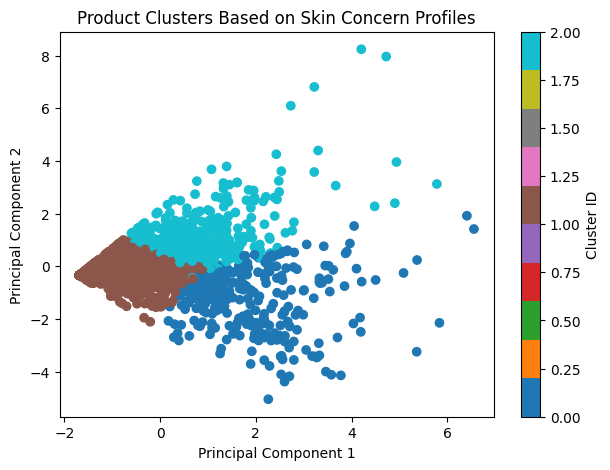

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(Xs)

plot_df = product_concerns.copy()
plot_df["PC1"] = X_pca[:, 0]
plot_df["PC2"] = X_pca[:, 1]

# Make the figure and draw the scatter
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster_id"],
    cmap="tab10"
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Product Clusters Based on Skin Concern Profiles")
fig.colorbar(sc, ax=ax, label="Cluster ID")


fig.savefig("outputs/figures/pca_clusters.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

In [11]:
#CLuster evaluation stage 
cluster_profiles = (
    product_concerns
    .groupby("cluster_id")[[
        "acne_rate",
        "dryness_rate",
        "irritation_rate",
        "n_reviews"
    ]]
    .mean()
    .sort_index()
)

cluster_profiles

cluster_profiles["dominant_concern"] = (
    cluster_profiles[[
        "acne_rate",
        "dryness_rate",
        "irritation_rate"
    ]]
    .idxmax(axis=1)
    .str.replace("_rate","")
)

cluster_profiles


,acne_rate,dryness_rate,irritation_rate,n_reviews,dominant_concern
cluster_id,,,,,
0,0.707984,0.240304,0.506234,544.584416,acne
1,0.101115,0.137007,0.159402,375.378341,irritation
2,0.169867,0.486991,0.267945,646.503425,dryness


In [12]:
#Identify and label clusters
cluster_label_map = cluster_profiles["dominant_concern"].to_dict()
cluster_label_map

{0: 'acne', 1: 'irritation', 2: 'dryness'}

In [14]:
#Mapping common ingredients stage

import pandas as pd
import numpy as np
import ast
import re

product_ID_col = "product_id"
CLUSTER_COL = "cluster_id"
raw_ingredients = "ingredients"

def parse_list_string(x): #cleaning the data and representing the ingredients as a python list
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return v
    except Exception:
        pass
    return [s]

def split_items(item): 
    parts = re.split(r",\s*(?![^()]*\))", str(item))
    return [p.strip() for p in parts if p.strip()]

def clean_token(s): #stripping the data of certain spaces and characters
    s = str(s).lower().strip()
    s = re.sub(r"\(.*?\)", " ", s)
    s = re.sub(r"\b\d+(\.\d+)?\s*%\b", " ", s)
    s = re.sub(r"[^a-z0-9\s\/\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = s.replace("aqua/water/eau", "water").replace("water/aqua/eau", "water").replace("aqua water eau", "water") #replacing water alike ingredients as just water
    return s

cluster_products = skincare_products[[product_ID_col, raw_ingredients]].merge( #keeping products that exist in both datasets where skincare products gives us product info and product concerns gives us cluster info
    product_concerns[[product_ID_col, CLUSTER_COL]],
    on=product_ID_col,
    how="inner"
)

cluster_products["ingredient_items"] = cluster_products[raw_ingredients].apply(parse_list_string) #ensure each product has a list of ingredients

df_long = ( #convert to a longer format where we have one row per ingredient item
    cluster_products[[product_ID_col, CLUSTER_COL, "ingredient_items"]]
    .explode("ingredient_items")
    .rename(columns={"ingredient_items": "inci_item"})
    .dropna(subset=["inci_item"])
)

df_long["ingredient_list"] = df_long["inci_item"].apply(split_items) #split the long format into each ingredients separated by commas

df_long = (
    df_long[[product_ID_col, CLUSTER_COL, "ingredient_list"]] #repeat the same process for one row per ingredient item
    .explode("ingredient_list")
    .rename(columns={"ingredient_list": "ingredient"})
    .dropna(subset=["ingredient"])
)

df_long["ingredient"] = df_long["ingredient"].apply(clean_token) #clean ingredient strings more and remove certain common keywords
df_long = df_long[df_long["ingredient"].str.len() >= 2]
df_long = df_long[~df_long["ingredient"].isin({"", "and", "or", "may contain", "contains"})]
TOP_N = 20 #we want the top 20 ingredients per cluster

top_common = ( #returns a dataframe with the top common ingredients per cluster
    df_long
    .drop_duplicates([CLUSTER_COL, product_ID_col, "ingredient"])
    .groupby([CLUSTER_COL, "ingredient"])
    .size()
    .reset_index(name="n_products")
    .sort_values([CLUSTER_COL, "n_products"], ascending=[True, False])
    .groupby(CLUSTER_COL)
    .head(TOP_N)
    .reset_index(drop=True)
)

tables_by_cluster = {}
for cid, t in top_common.groupby(CLUSTER_COL):
    t = t.sort_values("n_products", ascending=False).reset_index(drop=True)
    tables_by_cluster[cid] = t
    display(t)
    t.to_csv(
        f"outputs/tables/top_ingredients_cluster_{cid}.csv",
        index=False
    )


<unknown>:1: SyntaxWarning: invalid escape sequence '\A'
<unknown>:1: SyntaxWarning: invalid escape sequence '\A'


,cluster_id,ingredient,n_products
0,0,glycerin,213
1,0,water,208
2,0,phenoxyethanol,162
3,0,butylene glycol,131
4,0,sodium hydroxide,121
5,0,citric acid,116
6,0,propanediol,114
7,0,ethylhexylglycerin,104
8,0,xanthan gum,102
9,0,tocopherol,90


,cluster_id,ingredient,n_products
0,1,glycerin,1042
1,1,water,878
2,1,phenoxyethanol,746
3,1,butylene glycol,642
4,1,tocopherol,613
5,1,citric acid,569
6,1,sodium hyaluronate,524
7,1,caprylyl glycol,502
8,1,propanediol,502
9,1,xanthan gum,501


,cluster_id,ingredient,n_products
0,2,glycerin,464
1,2,water,383
2,2,phenoxyethanol,304
3,2,butylene glycol,271
4,2,tocopherol,252
5,2,sodium hyaluronate,245
6,2,citric acid,242
7,2,ethylhexylglycerin,210
8,2,xanthan gum,210
9,2,propanediol,202


In [15]:
skincare_reviews_scored.to_csv(
    "outputs/tables/review_reaction_scores.csv",
    index=False
)
product_concerns.to_csv(
    "outputs/tables/product_concern_profiles.csv",
    index=False
)
results_df.to_csv(
    "outputs/tables/k_sweep_metrics.csv",
    index=False
)
cluster_profiles.to_csv(
    "outputs/tables/cluster_profiles.csv"
)
plt.savefig(
    "outputs/figures/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>